In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 80)

df = pd.read_csv('data/survey.csv')
df.shape

(5000, 16)

### 1. Exploring data

In [2]:
# what features are there, what does the data look like, etc.
# ICorPM = individual contributor or project manager
df.head(3)

,ResponseId,Age,EdLevel,Employment,WorkExp,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,Industry,Country,Currency,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,annual_salary_usd
0,1,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8.0,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,Fintech,Ukraine,EUR European Euro,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,61256.0
1,10004,55-64 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,40.0,46.0,"Developer, full-stack","10,000 or more employees",Individual contributor,"Your choice (very flexible, you can come in wh...",Computer Systems Design and Services,Germany,EUR European Euro,C#;Java;SQL,H2;MariaDB;Neo4J;Oracle,99773.0
2,10016,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,2.0,5.0,"Developer, full-stack","10,000 or more employees",Individual contributor,Remote,Healthcare,United States of America,USD United States dollar,Bash/Shell (all shells);C#;HTML/CSS;JavaScript...,Microsoft SQL Server;MongoDB,85000.0


In [3]:
print("total length: ", len(df))
pd.DataFrame({
    'dtype':  df.dtypes,
    'nulls':  df.isna().sum(),
    'null%': (df.isna().mean() * 100).round(1),
    'unique': df.nunique(),
})

total length:  5000


,dtype,nulls,null%,unique
ResponseId,int64,0,0.0,5000
Age,object,0,0.0,7
EdLevel,object,5,0.1,8
Employment,object,0,0.0,6
WorkExp,float64,52,1.0,54
YearsCode,float64,21,0.4,57
DevType,object,0,0.0,32
OrgSize,object,530,10.6,9
ICorPM,object,602,12.0,2
RemoteWork,object,553,11.1,5


### What the columns mean

| Column | Meaning |
|---|---|
| `ResponseId` | Survey row ID — no signal |
| `Age` | Age bracket |
| `EdLevel` | Highest education completed |
| `Employment` | Employed / freelance / student / not employed / retired |
| `WorkExp` | Years of professional experience |
| `YearsCode` | Years coding at all, incl. hobby — starts earlier, so runs higher |
| `DevType` | Job role (32 values) |
| `OrgSize` | Employer headcount bracket |
| `ICorPM` | Individual contributor vs. people manager |
| `RemoteWork` | Remote / hybrid / in-person |
| `Industry` | Employer sector (15 values) |
| `Country` | Country of residence (130 values) |
| `Currency` | Currency pay was reported in |
| `LanguageHaveWorkedWith` | Languages used in past year, `;`-separated |
| `DatabaseHaveWorkedWith` | Databases used in past year, `;`-separated |
| `annual_salary_usd` | **Target** — annual pay converted to USD |

Takeaways:
- Most columns are text, need to do encoding
- This is a FORM:
    - Some questions are optional (null fields): edlevel, workexp (people can be unemployed), etc.
    - There are conditional sections
- Language have worked with/db have worked with have a lot of unique values, they are not categories

In [4]:
print("duplicate rows:", df.duplicated().sum())
print("duplicate response ids:", df.ResponseId.duplicated().sum())

duplicate rows: 0
duplicate response ids: 0


### 2. The target: `annual_salary_usd`

In [5]:
s = df['annual_salary_usd']
print('missing:', s.isna().sum())
print(s.describe().round(0))
s.quantile([0, .001, .01, .05, .25, .5, .75, .95, .99, .999, 1]).round(0)

missing: 84
count       4916.0
mean       98353.0
std       145434.0
min            1.0
25%        41765.0
50%        77559.0
75%       123993.0
max      6890299.0
Name: annual_salary_usd, dtype: float64


0.000          1.0
0.001          3.0
0.010         86.0
0.050       3988.0
0.250      41765.0
0.500      77559.0
0.750     123993.0
0.950     232029.0
0.990     500000.0
0.999    1291669.0
1.000    6890299.0
Name: annual_salary_usd, dtype: float64

In [6]:
# How many values are implausible as an *annual* salary?
for t in [10, 100, 1_000, 5_000]:
    print(f'below ${t:>7,}: {(s < t).sum():>4}')
for t in [300_000, 500_000, 1_000_000]:
    print(f'above ${t:>9,}: {(s > t).sum():>4}')

# Who are they? A few of the extremes, with context.
df.nsmallest(5, 'annual_salary_usd')[['Country', 'Currency', 'Employment', 'WorkExp', 'annual_salary_usd']]

below $     10:   12
below $    100:   58
below $  1,000:  124
below $  5,000:  282
above $  300,000:  107
above $  500,000:   46
above $1,000,000:    8


,Country,Currency,Employment,WorkExp,annual_salary_usd
306,Indonesia,IDR\tIndonesian rupiah,Employed,5.0,1.0
2192,Colombia,COP\tColombian peso,"Independent contractor, freelancer, or self-em...",1.0,1.0
2842,China,CNY\tChinese Yuan Renminbi,Employed,8.0,1.0
3766,Bangladesh,USD United States dollar,Employed,16.0,2.0
3142,Taiwan,TWD New Taiwan dollar,Employed,8.0,3.0


In [7]:
df.nlargest(5, 'annual_salary_usd')[['Country', 'Currency', 'Employment', 'WorkExp', 'annual_salary_usd']]

,Country,Currency,Employment,WorkExp,annual_salary_usd
3236,Ukraine,UAH Ukrainian hryvnia,"Independent contractor, freelancer, or self-em...",15.0,6890299.0
1858,India,USD United States dollar,Employed,6.0,2500000.0
2896,United States of America,USD United States dollar,Employed,15.0,2000000.0
4493,United States of America,USD United States dollar,Employed,11.0,1950000.0
3294,Finland,EUR European Euro,Employed,20.0,1740220.0


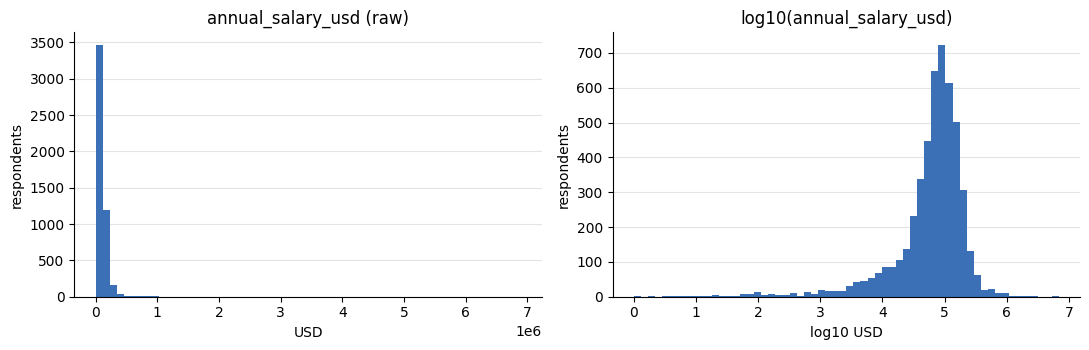

In [8]:
# Distribution. Raw dollars are unreadable because of the right tail, so plot log10 as well.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
HUE = '#3B6FB6'

axes[0].hist(s.dropna(), bins=60, color=HUE)
axes[0].set_title('annual_salary_usd (raw)')
axes[0].set_xlabel('USD')

axes[1].hist(np.log10(s[s > 0]), bins=60, color=HUE)
axes[1].set_title('log10(annual_salary_usd)')
axes[1].set_xlabel('log10 USD')

for ax in axes:
    ax.set_ylabel('respondents')
    ax.grid(axis='y', color='#E3E3E0', linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
plt.tight_layout()

Conclusions/decisions:
- Drop all rows that have no target value
- Trim everything outside of the bounds $504-$3M
    - $504 is the lowest minimum wage of the participating countries, [Nigeria](https://employsome.com/blog/minimum-wage-nigeria/)
    - $3M is 3x the highest recorded salary on levels.fyi (~$1M)
- Train the model on annual salaries logged

## 3. Column by column

Only the columns where I actually had to decide something get written up. The rest are noted
in passing.

### 3.1 `Country` and `Currency`

In [9]:
print('countries:', df.Country.nunique())
print('countries with <10 rows:', (df.Country.value_counts() < 10).sum())
df.Country.value_counts().head(12)

countries: 130
countries with <10 rows: 73


Country
United States of America                                1089
Germany                                                  441
United Kingdom of Great Britain and Northern Ireland     316
India                                                    262
France                                                   223
Canada                                                   175
Ukraine                                                  161
Brazil                                                   132
Italy                                                    130
Netherlands                                              127
Poland                                                   121
Australia                                                119
Name: count, dtype: int64

In [10]:
# Does country carry salary signal, and how much?
top = df.Country.value_counts().head(10).index
(df[df.Country.isin(top)]
   .groupby('Country')['annual_salary_usd']
   .agg(['count', 'median', 'max']).round(0)
   .sort_values('median'))

,count,median,max
Country,,,
India,242,18889.0,2500000.0
Ukraine,160,27152.0,6890299.0
Brazil,132,36407.0,210252.0
Italy,129,49886.0,197225.0
France,221,63808.0,696088.0
Netherlands,125,75410.0,1160147.0
Germany,437,82623.0,580073.0
Canada,170,87550.0,291833.0
United Kingdom of Great Britain and Northern Ireland,315,90194.0,748778.0


In [11]:
print('distinct Currency values:', df.Currency.nunique())
print('values containing a TAB character:', df.Currency.str.contains('\t').sum())
df.Currency.value_counts().head(10)

distinct Currency values: 97
values containing a TAB character: 1133


Currency
EUR European Euro           1460
USD United States dollar    1323
GBP Pound sterling           315
INR Indian rupee             254
CAD Canadian dollar          172
BRL Brazilian real           120
AUD\tAustralian dollar       117
PLN Polish zloty             112
SEK\tSwedish krona            94
UAH Ukrainian hryvnia         87
Name: count, dtype: int64

**Observation.** `Country` has 130 values but the distribution is extremely lopsided: the US
alone is 1,089 rows (22%), while **73 countries have fewer than 10 rows each**. It is also the
strongest signal in the dataset — among the ten largest countries the median salary runs from
$18,889 (India) to $150,000 (US), an 8× spread, far wider than anything experience or education
does. `Currency` has 97 values, **1,133 of them contain a literal tab character** (`AUD\tAustralian
dollar` vs `USD United States dollar`), and it is essentially a re-labelling of `Country`:
1,088 of 1,089 US rows say USD.

**Decision.** Keep `Country`, but collapse it to the **top 15 countries + "Other"**. Drop
`Currency` entirely.

**Why / what I rejected.**
- *One-hot encoding all 130 countries* (one 0/1 column per country) would add 130 columns where
  most have under 10 examples. The model can't learn a salary level from 3 people in Uruguay —
  it just memorises those 3 people, which looks great in training and fails on new data.
  Grouping the tail into "Other" costs almost nothing: those countries are individually rare
  and collectively still get a bucket.
- *Target encoding* (replacing each country with its average salary) is the fancier option and
  usually works better, but it has a trap: compute those averages before splitting the data and
  information from the test rows leaks into training, making the final score a lie. Top-15
  grouping gives most of the benefit with none of that risk, and I can explain it in one line.
- *Keeping `Currency`.* It's `Country` wearing a hat — it would add up to 97 mostly-duplicate
  columns and the tab characters mean the same currency can appear as two different values. The
  one case where it isn't redundant is people paid in a foreign currency (only 53% of Ukrainian
  respondents report UAH; the rest are paid in USD/EUR, and those are likely outsourcing jobs
  that pay above the local rate). A `paid_in_foreign_currency` flag would capture that in one
  column — noted as a future improvement rather than built now.

### 3.2 `Employment`

In [12]:
df.groupby('Employment')['annual_salary_usd'].agg(['count', 'median']).round(0)

,count,median
Employment,,
Employed,4189,78890.0
I prefer not to say,8,123008.0
"Independent contractor, freelancer, or self-employed",573,78890.0
Not employed,70,73289.0
Retired,5,72000.0
Student,71,16242.0


**Observation.** Six employment statuses. The bulk is `Employed` (4,189, median $78,890) and
`Independent contractor / freelancer / self-employed` (573, median also $78,890 — the same
figure, another sign of those converted round numbers). The rest are small and don't describe a
working developer's pay: 71 students (median **$16,242**), 70 not employed, 5 retired, 8 who
preferred not to say. The not-employed median of $73,289 is suspiciously normal, which suggests
those people answered about their most recent or expected job rather than current income.

**Decision.** Keep `Employed` and the self-employed/contractor rows (4,762). Drop students, the
not-employed, the retired and "prefer not to say" — 154 rows, about 3%. Keep the column itself
as a feature, since employee vs. contractor is a real pay difference.

**Why / what I rejected.**
- The question I'm answering is "what does a working developer earn". A student's $16k stipend
  and a retiree's number are answers to a different question, and leaving them in teaches the
  model a genuine pattern ("student → low") that has nothing to do with how developer pay is
  set. The not-employed rows are worse: their salary figure doesn't correspond to their other
  answers at all.
- *Keeping everyone* is the defensible alternative and I'd say so out loud — it's only 3% of the
  data, so the score barely moves either way. I chose the cleaner target definition over the
  extra rows because it makes the model's output easier to describe.
- *Dropping the column after filtering* — no. Two levels are left (employee vs. contractor) and
  they're worth one column.

### 3.3 Experience: `WorkExp` and `YearsCode`

In [13]:
print(df[['WorkExp', 'YearsCode']].describe().round(1))
print('\ncorrelation:', df[['WorkExp', 'YearsCode']].corr().iloc[0, 1].round(3))
print('rows where WorkExp > YearsCode:', (df.WorkExp > df.YearsCode).sum())
print('rows at the 100 ceiling:', ((df.WorkExp == 100) | (df.YearsCode == 100)).sum())

       WorkExp  YearsCode
count   4948.0     4979.0
mean      13.1       17.7
std        9.7       10.5
min        1.0        1.0
25%        6.0       10.0
50%       11.0       15.0
75%       18.0       25.0
max      100.0      100.0

correlation: 0.889
rows where WorkExp > YearsCode: 199
rows at the 100 ceiling: 2


In [14]:
df[df.WorkExp > df.YearsCode][['Age', 'WorkExp', 'YearsCode', 'annual_salary_usd']].head()

,Age,WorkExp,YearsCode,annual_salary_usd
14,25-34 years old,8.0,5.0,36758.0
51,25-34 years old,8.0,7.0,55000.0
99,35-44 years old,20.0,16.0,355000.0
153,35-44 years old,20.0,11.0,180000.0
154,55-64 years old,35.0,30.0,52903.0


**Observation.** The two columns say almost the same thing: correlation **0.889**. `YearsCode`
runs higher (median 15 vs. 11) which makes sense — people code as a hobby before they're paid
for it. Two problems, both smaller than they first look:
- **199 rows have `WorkExp` > `YearsCode`** — more years of professional work than years of
  coding at all, which is contradictory.
- Both columns max out at exactly **100**, but only **2 rows** actually sit at that ceiling: one
  35–44-year-old claiming 100 years of both (earning $444k), and one claiming 100 years of work,
  8 of coding, and a $182 salary. Beyond the ceiling itself, only 7 rows exceed 50 years of work
  experience and 1 exceeds 60 years of coding.

**Decision.** Keep both columns. Set `WorkExp > 50` and `YearsCode > 60` to missing (`NaN`)
rather than deleting those rows. Leave the 199 mild contradictions as they are. Add one derived
column, `YearsCode - WorkExp` ("years coding before the career started").

**Why / what I rejected.**
- *Deleting the impossible rows.* One bad number doesn't invalidate a person's country, role and
  education. Turning the value into "missing" keeps the other 15 answers and lets the model
  treat it as unknown — the gradient boosting model handles `NaN` natively, so no filling is
  needed.
- *Dropping one of the two columns because they're 0.889 correlated.* For a tree-based model,
  correlated inputs are harmless. For the linear model they inflate coefficients, which is
  exactly why I use `Ridge` (linear regression with a penalty that stops any single coefficient
  running away) rather than plain `LinearRegression`. And 0.889 isn't 1.0 — the *gap* between
  them carries real information about who started early, which is why I keep it as its own
  column.
- *Deleting the 199 contradictory rows.* That's 4% of the data thrown away over what is most
  likely people misreading two similarly-worded questions. Checked against age brackets, only
  **19 rows** are impossible even if you assume the person is at the top of their age bracket —
  too few to matter.
- *Clipping at the 99th percentile.* Arbitrary, and it would also trim honest 40-year careers.
  "Nobody has worked 50+ years" is a human bound I can justify.

### 3.4 Ordered categoricals: `Age`, `EdLevel`, `OrgSize`

In [15]:
for col in ['Age', 'EdLevel', 'OrgSize']:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False), '\n')

--- Age ---
Age
25-34 years old      1892
35-44 years old      1578
45-54 years old       664
18-24 years old       545
55-64 years old       270
65 years or older      45
Prefer not to say       6
Name: count, dtype: int64 

--- EdLevel ---
EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          2283
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       1464
Some college/university study without earning a degree                                 578
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         242
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     212
Associate degree (A.A., A.S., etc.)                                                    150
Other (please specify):                                                                 48
Primary/elementary school                                                               18
NaN                   

**Observation.** All three are buckets with a real order, stored as text — and each one has an
escape hatch that sits outside that order:
- `Age`: 6 real brackets, plus `Prefer not to say` (6 rows).
- `EdLevel`: primary → secondary → some college → associate → bachelor's → master's →
  professional, plus `Other (please specify):` (48) and 5 blanks.
- `OrgSize`: "Less than 20" → "10,000 or more" plus `Just me - I am a freelancer` (116),
  `I don't know` (47), and **530 blanks** (10.6%).

**Decision.** Map each to a single number using a sensible midpoint of the bucket, and send the
escape hatches to `NaN`:
- `Age` → 21, 30, 40, 50, 60, 70
- `OrgSize` → 1 (just me), 10, 50, 300, 750, 2500, 7500, 20000
- `EdLevel` → an ordered rank roughly matching years of education (primary 1 … professional 7)

**Why / what I rejected.**
- *One-hot encoding* would turn each of these into 7–9 separate 0/1 columns and, more
  importantly, throw away the ordering — the model would have no way of knowing that 45–54 is
  older than 25–34, so it has to learn each bracket's salary from scratch instead of learning
  "older earns more". With 5,000 rows, information you hand the model for free is worth a lot.
- *Numbering them 0, 1, 2, 3…* keeps the order but claims the gaps are equal, and they aren't:
  the jump from "less than 20 employees" to "10,000+" is not the same size as one bucket step.
  Midpoints encode roughly the right distances.
- *Giving "I don't know" / "Prefer not to say" a number* (e.g. the middle) would be inventing
  information that isn't there. `NaN` is the honest answer and the final model reads `NaN` fine.
  Six people declining to state their age is not worth engineering around.
- Note for later: `Age` and `WorkExp` will be correlated, for the obvious reason. Same answer as
  in 3.3 — trees don't care, and `Ridge` is penalised.

### 3.5 Missingness — is it random?

In [16]:
miss = df.isna().mean().mul(100).round(1).sort_values(ascending=False)
miss[miss > 0]

DatabaseHaveWorkedWith    21.0
ICorPM                    12.0
RemoteWork                11.1
OrgSize                   10.6
LanguageHaveWorkedWith     7.0
Industry                   2.9
annual_salary_usd          1.7
WorkExp                    1.0
YearsCode                  0.4
EdLevel                    0.1
dtype: float64

In [17]:
# Does missingness track another column? (e.g. is ICorPM missing for the non-employed?)
pd.crosstab(df.Employment, df.ICorPM.isna(), normalize='index').round(2)

ICorPM,False,True
Employment,,
Employed,0.98,0.02
I prefer not to say,0.00,1.00
"Independent contractor, freelancer, or self-employed",0.33,0.67
Not employed,0.09,0.91
Retired,0.00,1.00
Student,0.61,0.39


**Observation.** The missing values are **not random, and that's the whole point**. The four
biggest gaps — `DatabaseHaveWorkedWith` (21%), `ICorPM` (12%), `RemoteWork` (11.1%),
`OrgSize` (10.6%) — line up almost exactly with *who the respondent is*. The crosstab shows
`ICorPM` (manager vs. individual contributor) is missing for 2% of employed people but **67% of
the self-employed, 91% of the not-employed and 100% of the retired**. `OrgSize` and `RemoteWork`
show the same pattern. This is a form skipping questions that don't apply to you — not data that
got lost. The blanks in the two skills columns behave differently again: people with no
`Database` answer earn about the same as everyone else ($74.5k vs $78.8k), but people with no
`Language` answer earn noticeably less ($58k vs $78.9k), so even the blank itself carries signal.

**Decision.** Never drop a row just because a field is blank. Per column type:
- **Text columns** (`OrgSize`, `RemoteWork`, `ICorPM`, `Industry`): keep missing as its own
  category — literally a `"Missing"` level in the one-hot encoding.
- **Number columns** (`WorkExp`, `YearsCode`): leave as `NaN` for the gradient boosting model,
  which splits on "is it missing" by itself. For the linear baseline, fill with the median and
  add a `_missing` 0/1 flag column so the model can tell filled-in from real.
- **Skills columns**: blank means "I use none" → all-zero indicator row (see 3.6).

**Why / what I rejected.**
- *Dropping rows with any missing value* would delete something like a third of the dataset, and
  — far worse — it would delete them non-randomly: mostly freelancers and the self-employed. The
  model would then be trained on salaried employees only while claiming to describe developers
  in general. That's the classic way to build a biased model without noticing.
- *Filling categoricals with the most common value* would put a freelancer with no employer into
  "In-person, 20–99 employees". That's not a neutral guess, it's a fabricated fact.
- A useful cross-check: because I already dropped the retired/not-employed/students in 3.2, a
  chunk of this missingness disappears on its own. What's left is mostly the self-employed, and
  for them "no `OrgSize`" is genuine information about their employment, which is exactly why it
  gets its own category rather than an imputed value.

### 3.6 Multi-select columns: `LanguageHaveWorkedWith`, `DatabaseHaveWorkedWith`

In [18]:
print(df.LanguageHaveWorkedWith.dropna().iloc[0])
print('distinct raw combinations:', df.LanguageHaveWorkedWith.nunique())

langs = df.LanguageHaveWorkedWith.dropna().str.split(';').explode()
print('distinct individual languages:', langs.nunique())
langs.value_counts().head(10)

Bash/Shell (all shells);Dart;SQL
distinct raw combinations: 2940
distinct individual languages: 42


LanguageHaveWorkedWith
JavaScript                 3213
HTML/CSS                   2957
SQL                        2895
Python                     2621
TypeScript                 2329
Bash/Shell (all shells)    2270
C#                         1382
Java                       1372
PowerShell                 1088
C++                         968
Name: count, dtype: int64

**Observation.** These aren't categories, they're lists: one row reads
`Bash/Shell (all shells);Dart;SQL`. Taken as raw strings there are **2,940 distinct combinations**
across ~4,650 answers — nearly unique per person, so as-is the column is useless to a model.
Split on `;` there are only **42 distinct languages**, and they're common enough to learn from:
JavaScript 3,213, HTML/CSS 2,957, SQL 2,895, Python 2,621. `DatabaseHaveWorkedWith` is the same
shape with 1,052 blanks (21%), which almost certainly means "I don't use one" rather than "the
answer was lost".

**Decision.** Multi-hot encode both: `str.get_dummies(sep=';')` gives one 0/1 column per language
and per database (a person with three languages gets three 1s). Blank → a row of zeros. Also
keep two summary columns, `n_languages` and `n_databases`.

**Why / what I rejected.**
- *Treating the raw string as a category* would create ~2,940 categories that mostly appear once.
  Nothing to learn from.
- *Only keeping the counts* ("this person knows 7 languages") is tempting because it's 1 column
  instead of ~50, but it says Rust and PHP are worth the same, and they demonstrably aren't. I
  keep the count **as well** because breadth of stack is its own signal, roughly a proxy for
  seniority.
- *Dropping these columns.* Real risk noted honestly: ~50 extra 0/1 columns on 4,700 rows is a
  lot of width, and much of what they capture (senior people use more tools) is already in
  `WorkExp`. So this is the one feature group I'll test with and without — if it doesn't improve
  the held-out score, it comes out, and I'll report that it did nothing rather than quietly
  keeping it.
- If the width does hurt, the cheap fallback is to keep only the ~20 most common languages and
  fold the rest into `n_other_languages`.

### 3.7 Remaining columns: `DevType`, `RemoteWork`, `ICorPM`, `ResponseId`

In [19]:
for col in ['DevType', 'RemoteWork', 'ICorPM']:
    print(f'--- {col} ({df[col].nunique()} values) ---')
    print(df[col].value_counts(dropna=False).head(8), '\n')

--- DevType (32 values) ---
DevType
Developer, full-stack                            1790
Developer, back-end                               932
Architect, software or solutions                  356
Developer, front-end                              253
Developer, desktop or enterprise applications     251
Developer, mobile                                 192
Developer, embedded applications or devices       182
DevOps engineer or professional                   134
Name: count, dtype: int64 

--- RemoteWork (5 values) ---
RemoteWork
Remote                                                                          1554
Hybrid (some remote, leans heavy to in-person)                                   894
Hybrid (some in-person, leans heavy to flexibility)                              819
In-person                                                                        613
Your choice (very flexible, you can come in when you want or just as needed)     567
NaN                                   

**Observation.**
- `DevType` — 32 values, hugely lopsided: `Developer, full-stack` is 1,790 rows while the tail is
  `System administrator` (6), `UX/UI` (4), `Financial analyst` (3). It also overlaps with
  `Employment`: "Retired" and "Student" appear here as *job roles*.
- `RemoteWork` — 5 values plus 553 blanks. Two of the five are both "Hybrid", and
  "Your choice (very flexible…)" is really about flexibility rather than location.
- `ICorPM` — only 2 values (individual contributor 3,844, people manager 554) plus 602 blanks,
  and manager-vs-IC is a genuine pay driver.
- `ResponseId` — unique per row by construction.

**Decision.** One-hot all three, with `"Missing"` kept as its own level. Collapse `DevType` to the
**top 12 roles + "Other"**. Keep `RemoteWork`'s five levels as they are. Drop `ResponseId`.

**Why / what I rejected.**
- *Ordinal encoding* (0/1/2/3) is wrong for all three — there's no order to encode. Numbering
  In-person 0, Hybrid 1, Remote 2 would tell the model that Remote is "twice" Hybrid, which is a
  statement about nothing.
- *Keeping all 32 `DevType` values.* Same argument as `Country`: a category with 3 rows gets
  memorised, not learned. Top 12 covers the great majority of rows and the rest still get a
  bucket. The `DevType = Retired/Student` rows mostly disappear with the 3.2 filter anyway.
- *Merging the two Hybrid options into one.* Defensible, and I nearly did it — but it only saves
  one column, and "leans heavy to in-person" vs. "leans heavy to flexibility" might genuinely
  price differently. Cheaper to keep them and let the model decide.
- *`ResponseId`.* It's a row number. Left in, a tree model will happily find fake patterns in it
  (respondents may be ordered by submission time, which correlates with region). Dropped.

## 4. Cleaning — applying the decisions above

Everything here traces back to a decision recorded in section 3. Nothing new gets decided in
this section.

In [20]:
clean = df.copy()

# --- rows -------------------------------------------------------------------
# No target -> nothing to learn from (84 rows).
clean = clean[clean.annual_salary_usd.notna()]

# Section 2: implausible as an *annual* salary. Lower bound is Nigeria's minimum
# wage (the lowest of any country here), upper bound is 3x the highest salary
# recorded on levels.fyi -- deliberately loose, so it only cuts the impossible.
clean = clean[clean.annual_salary_usd.between(504, 3_000_000)]

# Section 3.2: students / not-employed / retired are answering a different
# question than "what does a working developer earn".
clean = clean[clean.Employment.isin([
    'Employed',
    'Independent contractor, freelancer, or self-employed',
])]

# --- fixes ------------------------------------------------------------------
# Section 3.3: "nobody has worked 50+ years" is a human bound I can justify.
# Set to NaN rather than dropping the row -- one bad number doesn't invalidate
# a person's country, role and education.
clean.loc[clean.WorkExp   > 50, 'WorkExp']   = np.nan
clean.loc[clean.YearsCode > 60, 'YearsCode'] = np.nan

# Section 3.4: ordered buckets stored as text -> one number each, so the model
# gets the ordering for free. Anything NOT in these maps is an escape hatch
# ("Prefer not to say", "Other", "I don't know") and .map() sends it to NaN --
# correct, because it has no place on the scale.
ED_RANK = {
    'Primary/elementary school': 1,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 2,
    'Some college/university study without earning a degree': 3,
    'Associate degree (A.A., A.S., etc.)': 4,
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 5,
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 6,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 7,
}
# Midpoints, not 0/1/2/3 -- the gap from "<20" to "10,000+" is not one step.
ORG_MID = {
    'Just me - I am a freelancer, sole proprietor, etc.': 1,
    'Less than 20 employees': 10,       '20 to 99 employees': 50,
    '100 to 499 employees': 300,        '500 to 999 employees': 750,
    '1,000 to 4,999 employees': 2_500,  '5,000 to 9,999 employees': 7_500,
    '10,000 or more employees': 20_000,
}
AGE_MID = {
    '18-24 years old': 21, '25-34 years old': 30, '35-44 years old': 40,
    '45-54 years old': 50, '55-64 years old': 60, '65 years or older': 70,
}
clean['ed_rank']  = clean.EdLevel.map(ED_RANK)
clean['org_size'] = clean.OrgSize.map(ORG_MID)
clean['age_mid']  = clean.Age.map(AGE_MID)

# Section 3.3: the gap between the two experience columns is its own signal --
# years spent coding before the professional career started.
clean['code_before_career'] = clean.YearsCode - clean.WorkExp

print(f'{len(df)} rows in -> {len(clean)} rows out ({len(df) - len(clean)} removed)')

5000 rows in -> 4678 rows out (322 removed)


## 5. Features and train/test split

The split happens **before** anything is fitted, so nothing learned from the test rows can leak
into the training data.

In [21]:
from sklearn.model_selection import train_test_split

TARGET = 'annual_salary_usd'

# Sections 3.1 / 3.7: long tails. 130 countries but 73 have under 10 rows, and
# DevType's tail is 3-6 rows apiece. A one-hot column with 3 examples gets
# memorised, not learned. Keep the common values, lump the rest into "Other".
# Blanks become their own "Missing" level -- section 3.5 showed a blank means
# "this question didn't apply to me", which is itself information.
def lump(col, n):
    top = col.value_counts().head(n).index
    return col.where(col.isin(top), 'Other').fillna('Missing')

CATEGORICAL = ['country', 'devtype', 'remote', 'icorpm', 'industry', 'employment']
NUMERIC     = ['WorkExp', 'YearsCode', 'code_before_career',
               'ed_rank', 'org_size', 'age_mid']

feat = pd.DataFrame(index=clean.index)
feat['country']    = lump(clean.Country, 15)   # 3.1: top 15 + Other
feat['devtype']    = lump(clean.DevType, 12)   # 3.7: top 12 + Other
feat['remote']     = clean.RemoteWork.fillna('Missing')
feat['icorpm']     = clean.ICorPM.fillna('Missing')
feat['industry']   = clean.Industry.fillna('Missing')
feat['employment'] = clean.Employment          # 3.2: employee vs. contractor
for col in NUMERIC:
    feat[col] = clean[col]

# Section 3.6: these are lists, not categories. get_dummies(';') splits on the
# separator and gives one 0/1 column per language / database; a blank answer
# becomes a row of zeros ("I use none"). It's a per-row string parse, nothing
# is fitted, so doing it before the split leaks nothing.
langs = clean.LanguageHaveWorkedWith.fillna('').str.get_dummies(';').add_prefix('lang_')
dbs   = clean.DatabaseHaveWorkedWith.fillna('').str.get_dummies(';').add_prefix('db_')
feat['n_languages'] = langs.sum(axis=1)
feat['n_databases'] = dbs.sum(axis=1)

# Section 3.1: Currency is dropped (it's Country wearing a hat).
# Section 3.7: ResponseId is dropped (a row number a tree will happily overfit).
X = pd.concat([feat, langs, dbs], axis=1)

# Section 2: train on log(salary). It's right-skewed (skew 7.6 -> -1.3 after
# log) and its drivers are multiplicative -- a senior earns ~1.5x a junior, not
# "+$40k". In log space an equal error is an equal *percentage* error.
y = np.log(clean[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(3742, 86) (936, 86)


## 6. Baseline

A model's error only means something next to a naive alternative. Predicting the training
median for everyone is the dumbest defensible guess — anything I build has to beat it.

In [22]:
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score

# y is in log space, so exponentiate back to dollars before scoring -- an MAE
# in log units means nothing to a human, and I want every number in this
# notebook to be readable as "dollars this model was off by".
def report(name, y_true_log, y_pred_log):
    actual, pred = np.exp(y_true_log), np.exp(y_pred_log)
    return {
        'model': name,
        'MAE':   mean_absolute_error(actual, pred),
        'MedAE': median_absolute_error(actual, pred),
        'R2':    r2_score(actual, pred),
    }

# Dollars to the nearest dollar, R2 to 3 dp.
ROUNDING = {'MAE': 0, 'MedAE': 0, 'R2': 3}

# The dumbest defensible guess: predict the training median for everyone.
baseline_pred = np.full(len(y_test), y_train.median())
results = [report('baseline (median)', y_test, baseline_pred)]
pd.DataFrame(results).round(ROUNDING)

,model,MAE,MedAE,R2
0,baseline (median),58618.0,37544.0,-0.025


## 7. Model

_Say which model you picked and why — and what you compared it against. A model you can
explain beats one you can't._

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# One-hot the six categoricals; pass everything else (numerics + the 0/1
# language columns) straight through. handle_unknown='ignore' means a category
# that only shows up in the test split becomes all-zeros instead of crashing.
pre = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL)],
    remainder='passthrough',
)

# Section 3.5: for the models that can't read NaN, fill with the median AND add
# a 0/1 indicator column, so the model can tell a filled-in value from a real
# one. HistGradientBoosting splits on missingness natively, so it skips this.
imputer = SimpleImputer(strategy='median', add_indicator=True)

# Everything sits inside a Pipeline so the encoder and imputer are fitted on the
# training rows only and re-applied unchanged to the test rows. That is what
# stops test data leaking into the fit.
candidates = {
    # Linear, penalised. Ridge rather than LinearRegression because section 3.3
    # left two 0.889-correlated columns in; the penalty stops either
    # coefficient running away.
    'ridge': (Ridge(alpha=1.0), True),
    'random forest': (RandomForestRegressor(
        n_estimators=300, min_samples_leaf=3, random_state=42, n_jobs=-1), True),
    'gradient boosting': (HistGradientBoostingRegressor(random_state=42), False),
}

fitted = {}
for name, (estimator, needs_imputer) in candidates.items():
    steps = [('pre', pre)]
    if needs_imputer:
        steps.append(('impute', imputer))
    steps.append(('model', estimator))
    pipe = Pipeline(steps)
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    results.append(report(name, y_test, pipe.predict(X_test)))

pd.DataFrame(results).round(ROUNDING)

,model,MAE,MedAE,R2
0,baseline (median),58618.0,37544.0,-0.025
1,ridge,44380.0,21574.0,0.185
2,random forest,40148.0,19716.0,0.241
3,gradient boosting,40763.0,20069.0,0.236


## 8. Evaluation and error analysis

Where the model is wrong matters more than the headline number.

In [24]:
model = fitted['random forest']

err = clean.loc[X_test.index, ['Country']].copy()
err['actual']  = np.exp(y_test)
err['pred']    = np.exp(model.predict(X_test))
err['abs_err'] = (err.pred - err.actual).abs()
err['pct_err'] = err.abs_err / err.actual

# Does it collapse on high earners? (Median, not mean -- one $2M row would
# otherwise decide the whole answer.)
print('--- median error by salary quartile ---')
display(err.groupby(pd.qcut(err.actual, 4), observed=True)[['abs_err', 'pct_err']]
           .median().round(2))

# Is the error concentrated in one country?
print('--- median error by country (30+ test rows) ---')
by_country = err.groupby('Country')['abs_err'].agg(['count', 'median'])
display(by_country[by_country['count'] >= 30].sort_values('median').round(0))

# What is the model actually leaning on? Feature names have to come from the
# whole pipeline except the final step, because the imputer adds columns.
print('--- top 12 features ---')
names = model[:-1].get_feature_names_out()
display(pd.Series(model[-1].feature_importances_, index=names)
          .sort_values(ascending=False).head(12).round(3))

# Section 2 warned about this: exp(mean of logs) is the geometric mean, which
# sits below the arithmetic mean. Measure the bias rather than assume it.
print('mean predicted / mean actual:', round(err.pred.mean() / err.actual.mean(), 3))

--- median error by salary quartile ---


,abs_err,pct_err
actual,,
"(549.999, 44357.25]",14148.96,0.67
"(44357.25, 77730.0]",15685.07,0.26
"(77730.0, 120000.0]",20759.07,0.21
"(120000.0, 2000000.0]",47017.26,0.29


--- median error by country (30+ test rows) ---


,count,median
Country,,
France,50,14126.0
India,45,14214.0
Germany,83,14611.0
United Kingdom of Great Britain and Northern Ireland,54,18843.0
United States of America,193,31267.0


--- top 12 features ---


remainder__YearsCode                     0.231
cat__country_United States of America    0.186
remainder__WorkExp                       0.059
remainder__org_size                      0.040
remainder__n_languages                   0.036
remainder__code_before_career            0.029
cat__country_India                       0.028
cat__country_Other                       0.027
cat__country_Ukraine                     0.022
remainder__n_databases                   0.022
remainder__ed_rank                       0.017
remainder__age_mid                       0.016
dtype: float64

mean predicted / mean actual: 0.822


In [25]:
# Section 3.6 said I'd test the ~80 language/database columns and report the
# result either way rather than quietly keeping them. Refitting the winning
# model on three versions of X:
ablation = {
    'core features only':        feat.drop(columns=['n_languages', 'n_databases']),
    'core + counts only':        feat,
    'core + counts + multi-hot': X,
}

rows = []
for label, X_variant in ablation.items():
    Xtr, Xte, ytr, yte = train_test_split(X_variant, y, test_size=0.2, random_state=42)
    pipe = Pipeline([
        ('pre', pre),
        ('impute', imputer),
        ('model', RandomForestRegressor(
            n_estimators=300, min_samples_leaf=3, random_state=42, n_jobs=-1)),
    ])
    pipe.fit(Xtr, ytr)
    rows.append({**report(label, yte, pipe.predict(Xte)), 'n_cols': X_variant.shape[1]})

pd.DataFrame(rows)[['model', 'n_cols', 'MAE', 'MedAE', 'R2']].round(3)

,model,n_cols,MAE,MedAE,R2
0,core features only,12,41777.829,20784.718,0.224
1,core + counts only,14,41844.163,21240.230,0.219
2,core + counts + multi-hot,86,40148.246,19715.654,0.241


## 9. Weaknesses and what I'd do differently

**Headline result.** Random forest on `log(salary)`: **MAE $40,148, median absolute error
$19,716, R² 0.241**, against a predict-the-median baseline of MAE $58,618 / MedAE $37,544.
Median error is roughly halved. Ridge and gradient boosting were both fitted on the identical
pipeline and came in behind (ridge MAE $44,380, GBM $40,763), so the choice was measured rather
than assumed.

**What this model can't do.**
It cannot predict high earners. Median error is $14–21k across the bottom three salary
quartiles but **$47,017 in the top quartile** — the tail is set by employer, equity and level,
none of which are columns in this survey. The same effect shows up geographically: median error
is $14,126 in France but **$31,267 in the US**, because US salaries are both larger and more
spread out. And the error is proportionally worst at the *bottom* — 67% median percentage error
in the lowest quartile, where being $14k off is the whole salary.

R² of 0.241 is close to the honest ceiling for ~15 survey columns about a person. The top
features are `YearsCode`, "is this person in the US", and `WorkExp` — which is most of the
story, and it's a story about coarse demographics, not about any individual's worth.

**The judgement call I'm least sure about.**
The $504 lower bound. It removes 99 rows, and I cannot distinguish a genuinely low salary in a
low-income country from someone who typed a *monthly* figure into an annual box. I picked a
bound I could justify from an outside source rather than an arbitrary percentile, but a
monthly-vs-annual detector — flagging values roughly 12× below their own country's median —
would be better targeted than a single global threshold.

Second: training on logs and exponentiating back returns the geometric mean, so predictions are
systematically low (see the ratio printed in section 8). I accepted that because proportional
accuracy mattered more to me than being unbiased in dollars, but it is a real bias and Duan's
smearing estimator is the standard correction.

**With another day, I would.**
1. Replace the single train/test split with k-fold cross-validation. With 936 test rows the
   metrics above carry real variance, and I'm quoting them to more precision than they deserve.
2. Add cost-of-living or PPP data per country. Country is doing most of the work, and raw USD
   conflates "is paid more" with "lives somewhere expensive" — this is also the optional API
   extension the brief suggests.
3. Build the `paid_in_foreign_currency` flag noted in 3.1. Only 53% of Ukrainian respondents
   report UAH; the rest are likely outsourcing roles paying above the local rate, and that is
   the one piece of signal `Currency` had that `Country` doesn't.